# Informe Técnico Comparativo: CNN vs MLP en Clasificación de Imágenes
**Machine Learning II — Unidad 2, Tema 1**

---

## 1. Análisis de Escala Paramétrica
Se compara la cantidad de parámetros entre un MLP totalmente conectado y una CNN para una imagen de entrada de 224×224×3.

In [1]:
# === Cálculo de parámetros: MLP vs CNN ===
import matplotlib.pyplot as plt
import numpy as np

# Entrada: imagen 224x224x3
H, W, C = 224, 224, 3
input_size = H * W * C
hidden_neurons = 512

# MLP: cada pixel conectado a cada neurona
params_mlp = input_size * hidden_neurons + hidden_neurons  # pesos + sesgos
print(f"Entrada aplanada: {input_size:,} valores")
print(f"Parámetros MLP (1ra capa): {params_mlp:,}")

# CNN: 96 filtros de 11x11x3 (estilo AlexNet)
n_filters = 96
k_h, k_w = 11, 11
params_per_filter = k_h * k_w * C + 1  # pesos + 1 sesgo
params_cnn = n_filters * params_per_filter
print(f"\nParámetros por filtro CNN: {params_per_filter}")
print(f"Parámetros CNN (1ra capa): {params_cnn:,}")

ratio = params_mlp / params_cnn
print(f"\n>>> El MLP tiene {ratio:,.0f}x más parámetros que la CNN <<<")

Entrada aplanada: 150,528 valores
Parámetros MLP (1ra capa): 77,070,848

Parámetros por filtro CNN: 364
Parámetros CNN (1ra capa): 34,944

>>> El MLP tiene 2,206x más parámetros que la CNN <<<


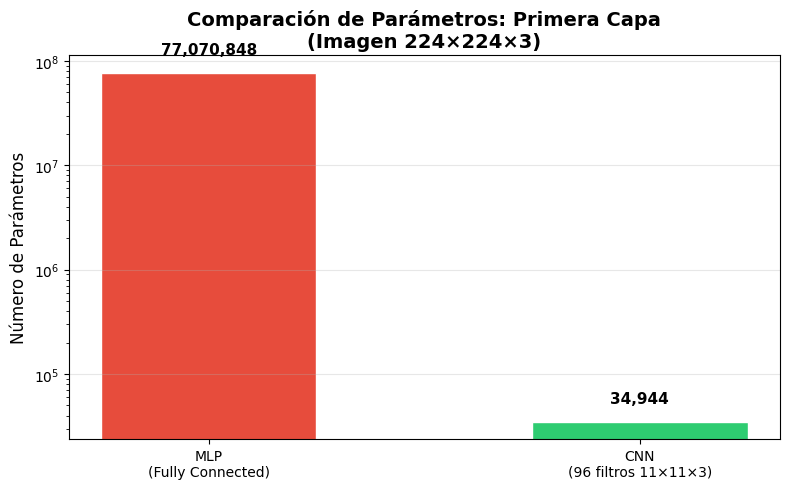

Reducción: 2,206 veces menos parámetros con CNN


In [2]:
# Gráfica comparativa
fig, ax = plt.subplots(figsize=(8, 5))
modelos = ['MLP\n(Fully Connected)', 'CNN\n(96 filtros 11×11×3)']
parametros = [params_mlp, params_cnn]
colors = ['#e74c3c', '#2ecc71']

bars = ax.bar(modelos, parametros, color=colors, edgecolor='white', width=0.5)
ax.set_ylabel('Número de Parámetros', fontsize=12)
ax.set_title('Comparación de Parámetros: Primera Capa\n(Imagen 224×224×3)', fontsize=14, fontweight='bold')
ax.set_yscale('log')
for bar, val in zip(bars, parametros):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.5, f'{val:,}', ha='center', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparacion_parametros.png', dpi=150)
plt.show()
print(f"Reducción: {ratio:,.0f} veces menos parámetros con CNN")

## 2. Análisis de Invarianza y Equivarianza a la Traslación
Se demuestra cómo un filtro convolucional detecta el mismo patrón independientemente de su ubicación.

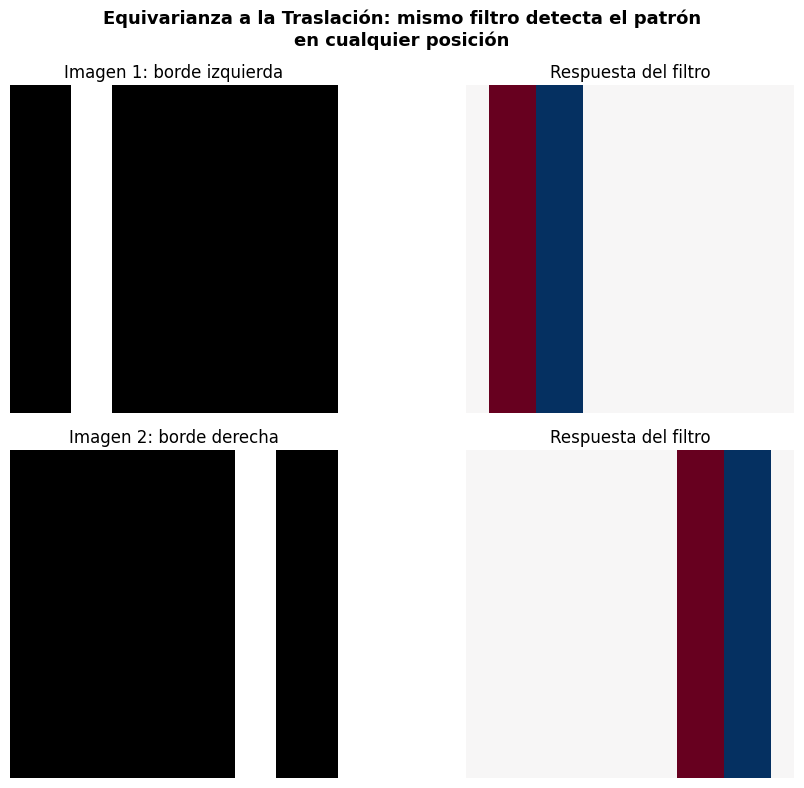

El mismo filtro (3 parámetros por fila) detecta bordes en CUALQUIER ubicación.
Un MLP necesitaría pesos diferentes para cada posición posible.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Crear imagen con un borde vertical en dos posiciones distintas
img1 = np.zeros((16, 16))
img1[:, 3:5] = 1  # borde a la izquierda

img2 = np.zeros((16, 16))
img2[:, 11:13] = 1  # borde a la derecha

# Filtro detector de bordes verticales
filtro = np.array([[-1, 0, 1],
                   [-1, 0, 1],
                   [-1, 0, 1]])

from scipy.signal import correlate2d
resp1 = correlate2d(img1, filtro, mode='valid')
resp2 = correlate2d(img2, filtro, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0,0].imshow(img1, cmap='gray'); axes[0,0].set_title('Imagen 1: borde izquierda')
axes[0,1].imshow(resp1, cmap='RdBu_r'); axes[0,1].set_title('Respuesta del filtro')
axes[1,0].imshow(img2, cmap='gray'); axes[1,0].set_title('Imagen 2: borde derecha')
axes[1,1].imshow(resp2, cmap='RdBu_r'); axes[1,1].set_title('Respuesta del filtro')
for ax in axes.flat: ax.axis('off')
fig.suptitle('Equivarianza a la Traslación: mismo filtro detecta el patrón\nen cualquier posición', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('equivarianza_traslacion.png', dpi=150)
plt.show()
print("El mismo filtro (3 parámetros por fila) detecta bordes en CUALQUIER ubicación.")
print("Un MLP necesitaría pesos diferentes para cada posición posible.")

## 3. Función del Max-Pooling
Se demuestra cómo Max-Pooling reduce la dimensionalidad e introduce invarianza local.

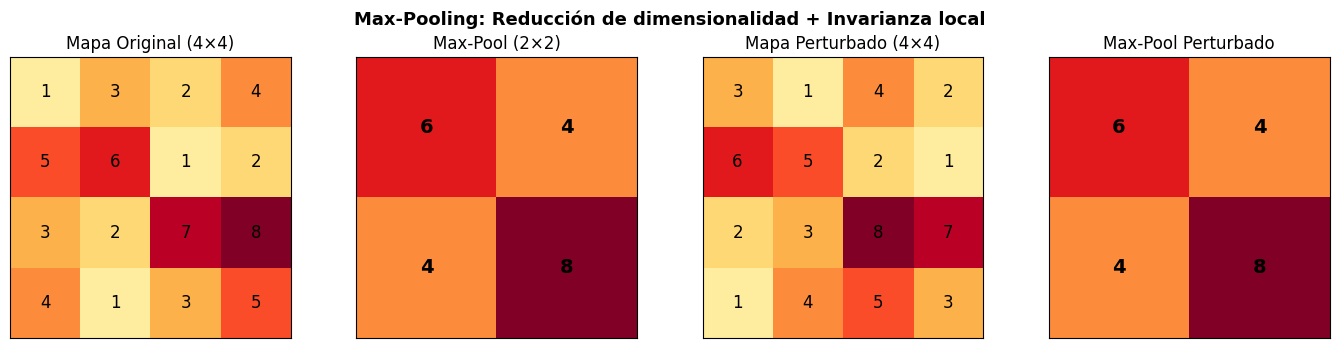

Original pooled: [6. 4. 4. 8.]
Perturbado pooled: [6. 4. 4. 8.]
Resultado IDÉNTICO a pesar de la perturbación -> Invarianza local
Reducción: de 16 valores a 4 valores (75% reducción)


In [4]:
# Demostración de Max-Pooling
feature_map = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [3, 2, 7, 8],
    [4, 1, 3, 5]
], dtype=float)

# Max-Pooling 2x2 con stride 2
def max_pool_2x2(x):
    h, w = x.shape
    out = np.zeros((h//2, w//2))
    for i in range(0, h, 2):
        for j in range(0, w, 2):
            out[i//2, j//2] = np.max(x[i:i+2, j:j+2])
    return out

pooled = max_pool_2x2(feature_map)

# Versión con leve desplazamiento (perturbación)
feature_map_shifted = np.array([
    [3, 1, 4, 2],
    [6, 5, 2, 1],
    [2, 3, 8, 7],
    [1, 4, 5, 3]
], dtype=float)
pooled_shifted = max_pool_2x2(feature_map_shifted)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
im0 = axes[0].imshow(feature_map, cmap='YlOrRd', vmin=0, vmax=8)
axes[0].set_title('Mapa Original (4×4)')
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f'{feature_map[i,j]:.0f}', ha='center', va='center', fontsize=12)

axes[1].imshow(pooled, cmap='YlOrRd', vmin=0, vmax=8)
axes[1].set_title('Max-Pool (2×2)')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{pooled[i,j]:.0f}', ha='center', va='center', fontsize=14, fontweight='bold')

axes[2].imshow(feature_map_shifted, cmap='YlOrRd', vmin=0, vmax=8)
axes[2].set_title('Mapa Perturbado (4×4)')
for i in range(4):
    for j in range(4):
        axes[2].text(j, i, f'{feature_map_shifted[i,j]:.0f}', ha='center', va='center', fontsize=12)

axes[3].imshow(pooled_shifted, cmap='YlOrRd', vmin=0, vmax=8)
axes[3].set_title('Max-Pool Perturbado')
for i in range(2):
    for j in range(2):
        axes[3].text(j, i, f'{pooled_shifted[i,j]:.0f}', ha='center', va='center', fontsize=14, fontweight='bold')

for ax in axes: ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Max-Pooling: Reducción de dimensionalidad + Invarianza local', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('maxpooling_demo.png', dpi=150)
plt.show()
print(f"Original pooled: {pooled.flatten()}")
print(f"Perturbado pooled: {pooled_shifted.flatten()}")
print("Resultado IDÉNTICO a pesar de la perturbación -> Invarianza local")
print(f"Reducción: de {feature_map.size} valores a {pooled.size} valores (75% reducción)")

## 4. Demostración Práctica: CNN vs MLP en CIFAR-10
Se entrena ambas arquitecturas en el dataset CIFAR-10 para comparar rendimiento real.

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Cargar CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0
print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print(f"Imagen: {x_train.shape[1]}x{x_train.shape[2]}x{x_train.shape[3]}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)
Imagen: 32x32x3


In [6]:
# --- Modelo MLP ---
mlp = keras.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='MLP')

mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mlp.summary()
print(f"\nTotal parámetros MLP: {mlp.count_params():,}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)


Total parámetros MLP: 1,707,274


In [7]:
# --- Modelo CNN ---
cnn = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='CNN')

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.summary()
print(f"\nTotal parámetros CNN: {cnn.count_params():,}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)


Total parámetros CNN: 122,570


In [8]:
# Comparación de parámetros
print("="*50)
print(f"Parámetros MLP: {mlp.count_params():>12,}")
print(f"Parámetros CNN: {cnn.count_params():>12,}")
print(f"Ratio MLP/CNN:  {mlp.count_params()/cnn.count_params():>12.1f}x")
print("="*50)

Parámetros MLP:    1,707,274
Parámetros CNN:      122,570
Ratio MLP/CNN:          13.9x


In [9]:
# Entrenar ambos modelos (10 épocas)
EPOCHS = 10

print("Entrenando MLP...")
hist_mlp = mlp.fit(x_train, y_train, epochs=EPOCHS, batch_size=64,
                   validation_data=(x_test, y_test), verbose=1)

print("\nEntrenando CNN...")
hist_cnn = cnn.fit(x_train, y_train, epochs=EPOCHS, batch_size=64,
                   validation_data=(x_test, y_test), verbose=1)

Entrenando MLP...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.3283 - loss: 1.8734 - val_accuracy: 0.4081 - val_loss: 1.6745
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.4065 - loss: 1.6624 - val_accuracy: 0.4126 - val_loss: 1.6237
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.4340 - loss: 1.5820 - val_accuracy: 0.4501 - val_loss: 1.5462
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.4542 - loss: 1.5302 - val_accuracy: 0.4607 - val_loss: 1.5097
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.4692 - loss: 1.4891 - val_accuracy: 0.4706 - val_loss: 1.5145
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.4866 - loss: 1.4509 - val_accuracy: 0.4671 - val_loss: 1.5060
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.4925 - loss: 1.4262 - val_accuracy: 0.4798 - val_loss: 1.4524
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.5026

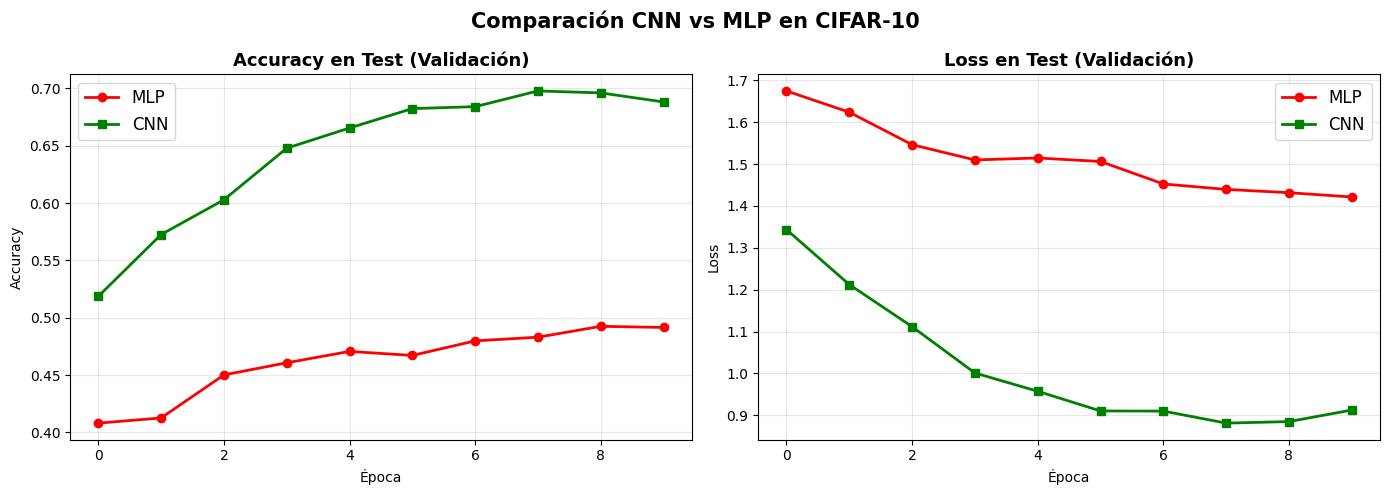

In [10]:
# Gráficas de resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(hist_mlp.history['val_accuracy'], 'r-o', label='MLP', linewidth=2)
axes[0].plot(hist_cnn.history['val_accuracy'], 'g-s', label='CNN', linewidth=2)
axes[0].set_title('Accuracy en Test (Validación)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=12); axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(hist_mlp.history['val_loss'], 'r-o', label='MLP', linewidth=2)
axes[1].plot(hist_cnn.history['val_loss'], 'g-s', label='CNN', linewidth=2)
axes[1].set_title('Loss en Test (Validación)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=12); axes[1].grid(alpha=0.3)

plt.suptitle('Comparación CNN vs MLP en CIFAR-10', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_vs_mlp_resultados.png', dpi=150)
plt.show()

In [11]:
# Evaluación final
loss_mlp, acc_mlp = mlp.evaluate(x_test, y_test, verbose=0)
loss_cnn, acc_cnn = cnn.evaluate(x_test, y_test, verbose=0)

print("\n" + "="*60)
print("         RESULTADOS FINALES EN CIFAR-10")
print("="*60)
print(f"{'Métrica':<20} {'MLP':>12} {'CNN':>12}")
print("-"*60)
print(f"{'Parámetros':<20} {mlp.count_params():>12,} {cnn.count_params():>12,}")
print(f"{'Accuracy Test':<20} {acc_mlp:>11.2%} {acc_cnn:>11.2%}")
print(f"{'Loss Test':<20} {loss_mlp:>12.4f} {loss_cnn:>12.4f}")
print("="*60)
print(f"\nLa CNN logra {acc_cnn-acc_mlp:.1%} más accuracy")
print(f"con {mlp.count_params()/cnn.count_params():.1f}x MENOS parámetros")


         RESULTADOS FINALES EN CIFAR-10
Métrica                       MLP          CNN
------------------------------------------------------------
Parámetros              1,707,274      122,570
Accuracy Test             49.15%      68.81%
Loss Test                  1.4214       0.9127

La CNN logra 19.7% más accuracy
con 13.9x MENOS parámetros


## 5. Conclusiones

Los resultados experimentales confirman el análisis teórico:

1. **Eficiencia paramétrica**: La CNN utiliza significativamente menos parámetros que el MLP gracias a la conectividad local y compartición de pesos.
2. **Equivarianza**: La CNN generaliza patrones espaciales sin importar su ubicación, lo que se traduce en mayor accuracy.
3. **Max-Pooling**: Reduce dimensionalidad e introduce invarianza local, actuando como regularizador implícito.

La arquitectura CNN es exponencialmente más eficiente y efectiva para clasificación de imágenes.